In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import xgboost as xgb

In [2]:
df = pd.read_csv(r"DATA\base.csv")
df.head()

,temporada_atual,rodada_atual,id_piloto_atual,posicao_quali_atual,q1_atual,q2_atual,q3_atual,target,id_circuito_atual,id_equipe_atual,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
0,2024,1,albon,13.0,90397.0,90221.0,NaN,15,bahrain,williams,...,NaN,NaN,NaN,NaN,NaN,18.23,23.65,48.82,0,0.0
1,2024,1,alonso,6.0,90179.0,89801.0,89542.0,9,bahrain,aston_martin,...,NaN,NaN,NaN,NaN,NaN,18.23,23.65,48.82,0,0.0
2,2024,1,bottas,16.0,90756.0,NaN,NaN,19,bahrain,sauber,...,NaN,NaN,NaN,NaN,NaN,18.23,23.65,48.82,0,0.0
3,2024,1,gasly,20.0,90948.0,NaN,NaN,18,bahrain,alpine,...,NaN,NaN,NaN,NaN,NaN,18.23,23.65,48.82,0,0.0
4,2024,1,hamilton,9.0,90451.0,89718.0,89710.0,7,bahrain,mercedes,...,NaN,NaN,NaN,NaN,NaN,18.23,23.65,48.82,0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temporada_atual               1090 non-null   int64  
 1   rodada_atual                  1090 non-null   int64  
 2   id_piloto_atual               1090 non-null   object 
 3   posicao_quali_atual           1086 non-null   float64
 4   q1_atual                      1073 non-null   float64
 5   q2_atual                      804 non-null    float64
 6   q3_atual                      530 non-null    float64
 7   target                        1090 non-null   int64  
 8   id_circuito_atual             1090 non-null   object 
 9   id_equipe_atual               1090 non-null   object 
 10  posicao_anterior              1016 non-null   object 
 11  grid_anterior                 1016 non-null   float64
 12  posicao_equipe_anterior       1028 non-null   float64
 13  pon

In [4]:
df.describe()

,temporada_atual,rodada_atual,posicao_quali_atual,q1_atual,q2_atual,q3_atual,target,grid_anterior,posicao_equipe_anterior,pontos_equipe_anterior,...,media_ultimas_3_anterior,media_ultimas_5_anterior,qtde_abandonos_anterior,media_posicao_ganha_anterior,tendencia_desempenho,temp_ar_media,temp_pista_media,umidade_media,corrida_molhada,perc_voltas_chuva
count,1090.000000,1090.000000,1086.000000,1073.000000,804.000000,530.000000,1090.000000,1016.000000,1028.000000,1028.000000,...,1004.000000,1006.000000,1023.000000,1004.000000,1004.000000,1090.000000,1090.000000,1090.000000,1090.000000,1090.000000
mean,2024.681651,11.422018,10.549724,84390.451072,83584.289801,83089.415094,10.603670,10.530512,5.549611,120.680934,...,9.542530,9.556799,0.899316,0.849831,-0.010398,22.998624,34.775670,55.139413,0.018349,4.177615
std,0.677957,7.152277,5.805195,11211.981139,10967.138002,10910.888533,5.842499,5.834419,2.911628,164.692406,...,4.615727,4.424109,1.099114,2.604545,1.342938,4.913978,9.346881,16.073874,0.134270,12.045075
min,2024.000000,1.000000,1.000000,64672.000000,64410.000000,63971.000000,1.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,0.000000,-7.000000,-7.500000,12.850000,17.720000,18.230000,0.000000,0.000000
25%,2024.000000,5.000000,6.000000,75733.000000,75311.250000,74810.250000,6.000000,5.000000,3.000000,11.750000,...,5.627500,5.600000,0.000000,-0.670000,-0.600000,18.640000,27.670000,44.450000,0.000000,0.000000
50%,2025.000000,11.000000,11.000000,83516.000000,83041.500000,82814.000000,11.000000,10.500000,6.000000,45.500000,...,10.000000,10.250000,1.000000,0.670000,0.000000,23.140000,35.600000,57.240000,0.000000,0.000000
75%,2025.000000,18.000000,16.000000,91107.000000,90112.250000,89705.250000,16.000000,16.000000,8.000000,162.000000,...,13.082500,13.000000,1.000000,2.330000,0.530000,27.050000,43.290000,67.330000,0.000000,0.000000
max,2026.000000,24.000000,22.000000,117775.000000,115716.000000,114810.000000,22.000000,22.000000,11.000000,800.000000,...,20.000000,20.000000,6.000000,14.000000,8.000000,33.100000,50.590000,85.260000,1.000000,58.200000


In [6]:
df.drop(columns=["id_piloto_atual", "posicao_anterior"], inplace=True)

In [7]:
X = df.drop(columns=['target'])
y = df['target']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [10]:
onehotencoder = ColumnTransformer(transformers=[
    ('OneHot', OneHotEncoder(handle_unknown='ignore'), ['id_circuito_atual', 'id_equipe_atual'])
], remainder='passthrough')

In [11]:
X_train_transformed = onehotencoder.fit_transform(X_train)
X_test_transformed = onehotencoder.transform(X_test)

In [12]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3 ,5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda': [0.5, 0.7, 1, 1.3]
}

xgb_model = xgb.XGBRegressor(random_state=42)

grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="neg_mean_absolute_error", n_iter=100, n_jobs=-1, verbose=2, random_state=42)
grid_search.fit(X_train_transformed, y_train)

best_xgb = grid_search.best_estimator_

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor MAE:", -grid_search.best_score_) 

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Melhores parâmetros: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
Melhor MAE: 3.212530827522278


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predicoes = best_xgb.predict(X_test_transformed)

mae = mean_absolute_error(y_test, predicoes)
rmse = np.sqrt(mean_squared_error(y_test, predicoes))

print(f"MAE teste:  {mae:.4f}")
print(f"RMSE teste: {rmse:.4f}")

MAE teste:  3.1945
RMSE teste: 4.2565


Entendendo as features utilizadas

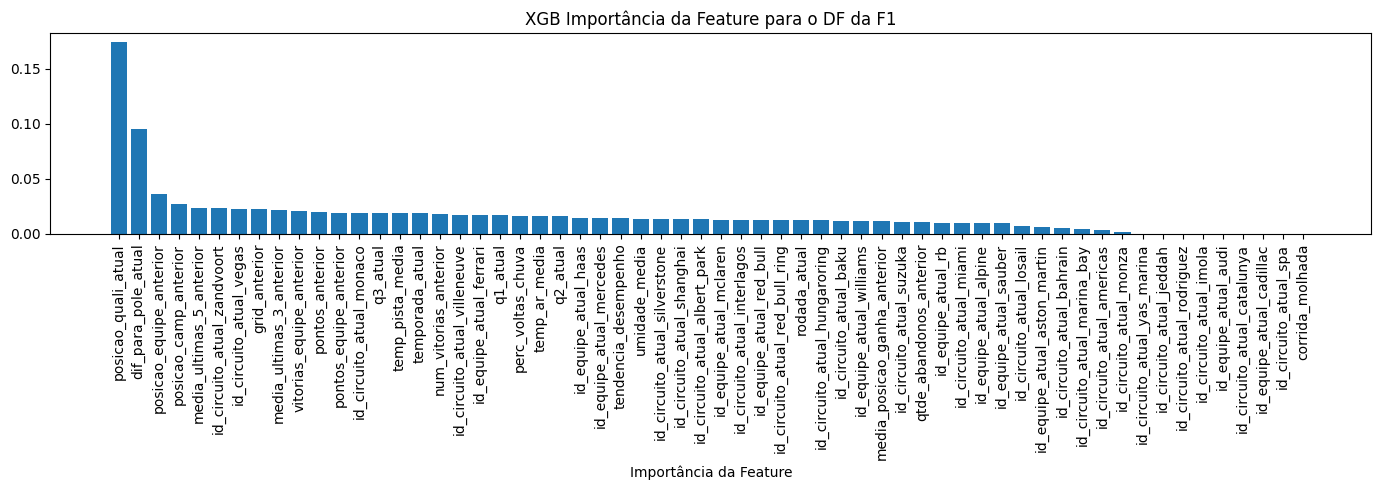

In [18]:
colunas_ohe = onehotencoder.named_transformers_['OneHot'].get_feature_names_out(['id_circuito_atual', 'id_equipe_atual'])
colunas_resto = [c for c in X.columns if c not in ['id_circuito_atual', 'id_equipe_atual']]
feature_names = list(colunas_ohe) + list(colunas_resto)

feature_importances = best_xgb.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(14, 5))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.xlabel("Importância da Feature")
plt.title("XGB Importância da Feature para o DF da F1")
plt.tight_layout()
plt.show()